In [32]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# Setup paths (relative to notebooks/ folder)
processed_path = Path("../data/processed")
clean_file_path = processed_path / "player_match_stats_clean.csv"

print("⏳ Step 1: Loading verified project dataset...")
df_base = pd.read_csv(clean_file_path)

# Ensure data sorting is strictly chronological for accurate time-series rolling windows
df_base['date'] = pd.to_datetime(df_base['date'])
df_base = df_base.sort_values('date').reset_index(drop=True)

print("⚙️ Step 2: Extracting base identifiers and targets...")
model_dataset = df_base[[
    'player_id', 
    'game_id', 
    'date', 
    'fantasy_points', 
    'market_value_in_eur',
    'position',
]].copy()

# Drop rows where position is null or the placeholder string 'Missing'
before = len(model_dataset)
model_dataset = model_dataset[
    model_dataset['position'].notna() & (model_dataset['position'] != 'Missing')
].copy()
after = len(model_dataset)
print(f"   Dropped {before - after:,} rows with missing/unknown position.")

# Label-encode position (4 categories → 0-3, stable across splits)
le = LabelEncoder()
model_dataset['position'] = le.fit_transform(model_dataset['position'])
print(f"   Position encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Sync df_base to the same row mask so rolling transforms stay aligned
df_base = df_base.loc[model_dataset.index].reset_index(drop=True)
model_dataset = model_dataset.reset_index(drop=True)

print("⚙️ Step 3: Running rolling feature pipeline via group transformations...")

grouped = df_base.groupby('player_id')

rolling_pipeline_specs = {
    "avg_fp_last_3": ("fantasy_points", 3, "mean"),
    "avg_fp_last_5": ("fantasy_points", 5, "mean"),
    "avg_goals_last_5": ("goals", 5, "mean"),
    "avg_assists_last_5": ("assists", 5, "mean"),
    "avg_minutes_last_5": ("minutes_played", 5, "mean"),
    "std_fp_last_5": ("fantasy_points", 5, "std"),
}

for feature_name, (source_col, window, metric) in rolling_pipeline_specs.items():
    if metric == "mean":
        model_dataset[feature_name] = grouped[source_col].transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=1).mean()
        )
    elif metric == "std":
        model_dataset[feature_name] = grouped[source_col].transform(
            lambda x: x.shift(1).rolling(window=window, min_periods=1).std()
        )

df_base['is_played'] = (df_base['minutes_played'] > 0).astype(int)
model_dataset['matches_played_last_5'] = df_base.groupby('player_id')['is_played'].transform(
    lambda x: x.shift(1).rolling(window=5, min_periods=1).sum()
)

model_dataset['std_fp_last_5'] = model_dataset['std_fp_last_5'].fillna(0)
model_dataset['matches_played_last_5'] = model_dataset['matches_played_last_5'].fillna(0).astype(int)

print("✅ Feature pipeline complete.\n")


# =====================================================================
# SYSTEM ALIGNMENT VERIFICATION PACK
# =====================================================================
print("=" * 80)
print("🧐 PIPELINE INTEGRITY CHECK: UNIFIED MODEL DATASET STRUCTURE")
print("=" * 80)

print(f"1. Unified Model Dataset Shape: {model_dataset.shape}")
print(f"2. Core Columns Realized:\n{model_dataset.columns.tolist()}\n")

print("📋 3. POSITION DISTRIBUTION (encoded):")
pos_map = dict(zip(le.transform(le.classes_), le.classes_))
print(model_dataset['position'].value_counts().rename(pos_map).sort_index().to_string())
print()

print("📋 4. MULTI-FEATURE TIMELINE FOR A SINGLE ACTIVE PLAYER PROFILE:")
print("-" * 80)
sample_player_id = df_base['player_id'].value_counts().index[0]
player_name_col = 'player_name' if 'player_name' in df_base.columns else 'name'
sample_name = df_base[df_base['player_id'] == sample_player_id][player_name_col].iloc[0]

print(f"Inspecting Player: {sample_name} (ID: {sample_player_id})\n")

verification_view = model_dataset[model_dataset['player_id'] == sample_player_id].sort_values('date')
display(verification_view.head(10))
print("=" * 80)

print("\n📊 5. STATISTICAL SUMMARIES FOR THE FINAL MODEL MATRIX:")
print("-" * 80)
display(model_dataset.describe().T)


# =====================================================================
# FINAL STORAGE COMMITMENT
# =====================================================================
output_path = processed_path / "model_dataset.csv"
model_dataset.to_csv(output_path, index=False)
print(f"\n💾 Saved aligned modeling table cleanly to: {output_path}")


⏳ Step 1: Loading verified project dataset...
⚙️ Step 2: Extracting base identifiers and targets...
   Dropped 1,493 rows with missing/unknown position.
   Position encoding: {'Attack': np.int64(0), 'Defender': np.int64(1), 'Goalkeeper': np.int64(2), 'Midfield': np.int64(3)}
⚙️ Step 3: Running rolling feature pipeline via group transformations...
✅ Feature pipeline complete.

🧐 PIPELINE INTEGRITY CHECK: UNIFIED MODEL DATASET STRUCTURE
1. Unified Model Dataset Shape: (1884195, 13)
2. Core Columns Realized:
['player_id', 'game_id', 'date', 'fantasy_points', 'market_value_in_eur', 'position', 'avg_fp_last_3', 'avg_fp_last_5', 'avg_goals_last_5', 'avg_assists_last_5', 'avg_minutes_last_5', 'std_fp_last_5', 'matches_played_last_5']

📋 3. POSITION DISTRIBUTION (encoded):
position
Attack        532199
Defender      634038
Goalkeeper    132407
Midfield      585551

📋 4. MULTI-FEATURE TIMELINE FOR A SINGLE ACTIVE PLAYER PROFILE:
------------------------------------------------------------------

,player_id,game_id,date,fantasy_points,market_value_in_eur,position,avg_fp_last_3,avg_fp_last_5,avg_goals_last_5,avg_assists_last_5,avg_minutes_last_5,std_fp_last_5,matches_played_last_5
5160,38253,2229332,2012-08-12,7,15000000.0,0,NaN,NaN,NaN,NaN,NaN,0.000000,0
7008,38253,2221749,2012-08-18,5,15000000.0,0,7.000000,7.000000,1.000000,0.000000,90.00,0.000000,1
9623,38253,2222535,2012-08-24,5,15000000.0,0,6.000000,6.000000,0.500000,0.500000,79.50,1.414214,2
13886,38253,2231387,2012-09-01,2,15000000.0,0,5.666667,5.666667,0.333333,0.666667,83.00,1.154701,3
17015,38253,2231428,2012-09-15,7,15000000.0,0,4.000000,4.750000,0.250000,0.500000,84.75,2.061553,4
19884,38253,2262154,2012-09-18,7,15000000.0,0,4.666667,5.200000,0.400000,0.400000,85.80,2.049390,5
21129,38253,2231414,2012-09-22,5,15000000.0,0,5.333333,5.200000,0.400000,0.400000,85.80,2.049390,5
24123,38253,2231403,2012-09-25,1,15000000.0,0,6.333333,5.200000,0.400000,0.400000,90.00,2.049390,5
28621,38253,2262178,2012-10-03,2,15000000.0,0,4.333333,4.400000,0.400000,0.200000,90.00,2.792848,5
32143,38253,2231435,2012-10-07,7,15000000.0,0,2.666667,4.400000,0.400000,0.200000,90.00,2.792848,5



📊 5. STATISTICAL SUMMARIES FOR THE FINAL MODEL MATRIX:
--------------------------------------------------------------------------------


,count,mean,min,25%,50%,75%,max,std
player_id,1884195.0,239670.546172,10.0,62163.0,174196.0,346291.0,1522779.0,223540.192176
game_id,1884195.0,3303855.214946,2211607.0,2609715.0,3210018.0,3890155.0,4882370.0,762372.404878
date,1884195,2019-08-28 19:30:34.004442,2012-07-03 00:00:00,2016-01-31 00:00:00,2019-10-06 00:00:00,2023-04-01 00:00:00,2026-05-24 00:00:00,NaN
fantasy_points,1884195.0,2.512267,-13.0,1.0,2.0,2.0,38.0,2.760955
market_value_in_eur,1855744.0,4644212.900594,10000.0,250000.0,700000.0,3000000.0,200000000.0,12251365.798571
position,1884195.0,1.409358,0.0,0.0,1.0,3.0,3.0,1.195087
avg_fp_last_3,1855546.0,2.531507,-8.0,1.333333,2.0,3.333333,24.0,1.776425
avg_fp_last_5,1855546.0,2.534517,-8.0,1.4,2.2,3.4,24.0,1.503482
avg_goals_last_5,1855546.0,0.096578,0.0,0.0,0.0,0.2,4.0,0.183299
avg_assists_last_5,1855546.0,0.075893,0.0,0.0,0.0,0.2,3.0,0.144578



💾 Saved aligned modeling table cleanly to: ../data/processed/model_dataset.csv


## Dataset Validation

In [33]:

from IPython.display import display

print("=" * 60)
print("🔍 INITIATING DATASET VALIDATION PROTOCOL")
print("=" * 60)

# Load the newly saved dataset
df = pd.read_csv("../data/processed/model_dataset.csv")

# ---------------------------------------------------------
# 1. Shape & Structure Check
# ---------------------------------------------------------
print("\n--- 1. SHAPE & STRUCTURE CHECK ---")
print(f"Dataset Shape: {df.shape[0]:,} rows | {df.shape[1]} columns")
print("\nVerifying first 5 rows:")
display(df.head())

print("\nDataset Info:")
# info() prints to sys.stdout by default, capturing it cleanly
df.info()

# ---------------------------------------------------------
# 2. Missing Value Audit
# ---------------------------------------------------------
print("\n--- 2. MISSING VALUE AUDIT ---")
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_percentages = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    '% of Total Data': missing_percentages
})

# Filter to only show columns that actually have missing values
missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

if missing_summary.empty:
    print("✅ Zero missing values detected across the dataset.")
else:
    print("⚠️ Missing values detected (expected from rolling windows):")
    display(missing_summary)

# ---------------------------------------------------------
# 3. Cold Start Analysis (History Depth)
# ---------------------------------------------------------
print("\n--- 3. COLD START ANALYSIS ---")
print("Frequency of 'matches_played_last_5':")
matches_played_counts = df["matches_played_last_5"].value_counts().sort_index()
display(matches_played_counts.to_frame(name='Row Count'))

# Calculate weak history proportion
weak_history_mask = df["matches_played_last_5"] < 3
weak_history_ratio = weak_history_mask.mean()
weak_history_count = weak_history_mask.sum()

print("\nWeak History Summary (< 3 matches played in last 5):")
print(f"Total Rows: {weak_history_count:,}")
print(f"Percentage of Dataset: {weak_history_ratio * 100:.2f}%")

print("\n" + "=" * 60)
print("🏁 VALIDATION COMPLETE")
print("=" * 60)

🔍 INITIATING DATASET VALIDATION PROTOCOL

--- 1. SHAPE & STRUCTURE CHECK ---
Dataset Shape: 1,884,195 rows | 13 columns

Verifying first 5 rows:


,player_id,game_id,date,fantasy_points,market_value_in_eur,position,avg_fp_last_3,avg_fp_last_5,avg_goals_last_5,avg_assists_last_5,avg_minutes_last_5,std_fp_last_5,matches_played_last_5
0,38004,2231978,2012-07-03,12,75000.0,0,NaN,NaN,NaN,NaN,NaN,0.0,0
1,63496,2235777,2012-07-05,2,125000.0,0,NaN,NaN,NaN,NaN,NaN,0.0,0
2,75109,2235769,2012-07-05,7,100000.0,1,NaN,NaN,NaN,NaN,NaN,0.0,0
3,84260,2235545,2012-07-05,7,50000.0,1,NaN,NaN,NaN,NaN,NaN,0.0,0
4,80073,2235545,2012-07-05,15,100000.0,0,NaN,NaN,NaN,NaN,NaN,0.0,0



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1884195 entries, 0 to 1884194
Data columns (total 13 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   player_id              int64  
 1   game_id                int64  
 2   date                   str    
 3   fantasy_points         int64  
 4   market_value_in_eur    float64
 5   position               int64  
 6   avg_fp_last_3          float64
 7   avg_fp_last_5          float64
 8   avg_goals_last_5       float64
 9   avg_assists_last_5     float64
 10  avg_minutes_last_5     float64
 11  std_fp_last_5          float64
 12  matches_played_last_5  int64  
dtypes: float64(7), int64(5), str(1)
memory usage: 186.9 MB

--- 2. MISSING VALUE AUDIT ---
⚠️ Missing values detected (expected from rolling windows):


,Missing Values,% of Total Data
avg_fp_last_3,28649,1.520490
avg_fp_last_5,28649,1.520490
avg_goals_last_5,28649,1.520490
avg_assists_last_5,28649,1.520490
avg_minutes_last_5,28649,1.520490
market_value_in_eur,28451,1.509982



--- 3. COLD START ANALYSIS ---
Frequency of 'matches_played_last_5':


,Row Count
matches_played_last_5,
0,28649
1,26187
2,24702
3,23721
4,22828
5,1758108



Weak History Summary (< 3 matches played in last 5):
Total Rows: 79,538
Percentage of Dataset: 4.22%

🏁 VALIDATION COMPLETE


📈 EXTENDED VALIDATION: DISTRIBUTIONS & CORRELATIONS

--- 4. FANTASY POINTS DISTRIBUTION ---


,Target (fantasy_points) Summary
count,1.884195e+06
mean,2.512267e+00
std,2.760955e+00
min,-1.300000e+01
25%,1.000000e+00
50%,2.000000e+00
75%,2.000000e+00
max,3.800000e+01


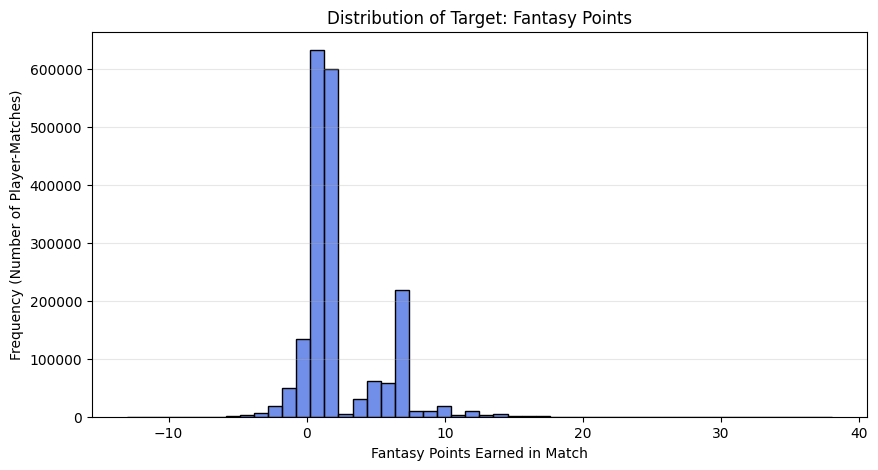


--- 5. SPEARMAN CORRELATION MATRIX ---
Spearman Correlation with target (fantasy_points):


,Spearman rho
fantasy_points,1.000000
avg_fp_last_5,0.191244
avg_fp_last_3,0.176298
avg_minutes_last_5,0.145223
avg_goals_last_5,0.135156
std_fp_last_5,0.101243
avg_assists_last_5,0.097421
market_value_in_eur,0.067194
matches_played_last_5,0.063116
position,-0.025846



Generating full feature correlation heatmap...


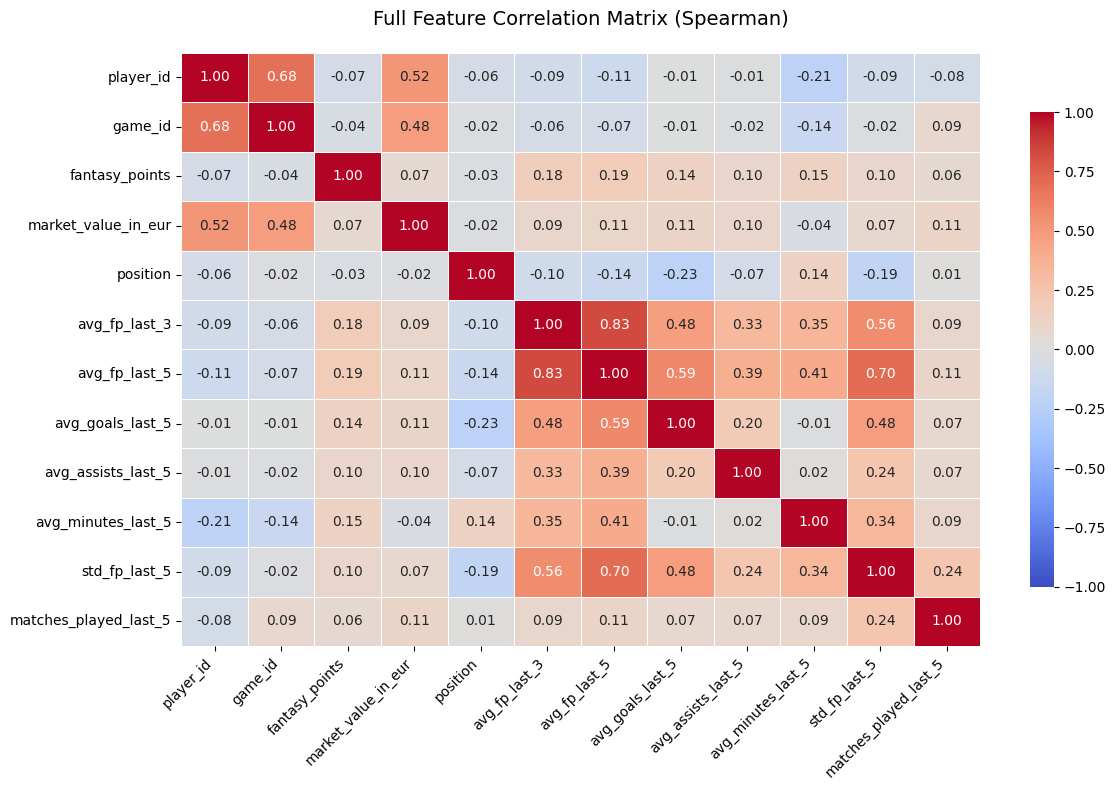


--- 6. TOP FEATURE SCATTER PLOTS (Sampled N=50,000) ---


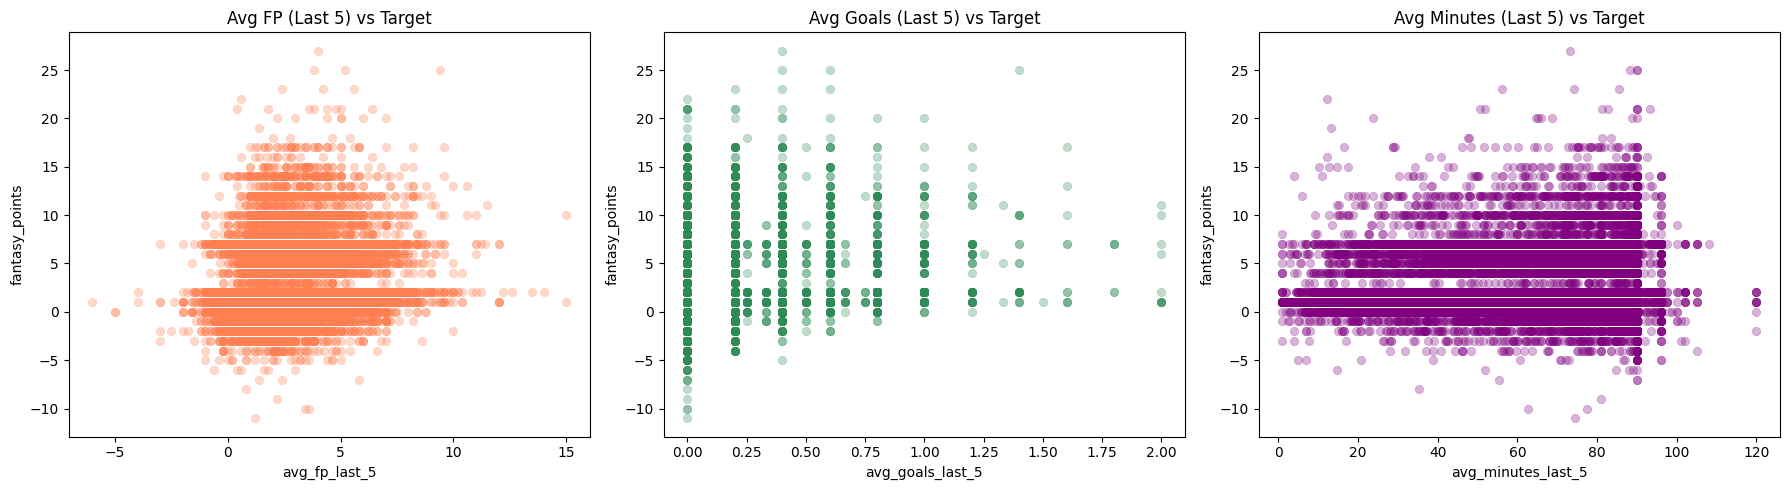


🏁 EXTENDED VALIDATION COMPLETE


In [35]:
print("=" * 60)
print("📈 EXTENDED VALIDATION: DISTRIBUTIONS & CORRELATIONS")
print("=" * 60)

# ---------------------------------------------------------
# 4. Fantasy Points Distribution
# ---------------------------------------------------------
print("\n--- 4. FANTASY POINTS DISTRIBUTION ---")
display(df["fantasy_points"].describe().to_frame(name='Target (fantasy_points) Summary'))

# Plotting the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["fantasy_points"], bins=50, color='royalblue', edgecolor='black')
plt.title("Distribution of Target: Fantasy Points")
plt.xlabel("Fantasy Points Earned in Match")
plt.ylabel("Frequency (Number of Player-Matches)")
plt.grid(axis='y', alpha=0.3)
plt.show()

# ---------------------------------------------------------
# 5. Spearman Correlation Matrix (All Features)
# ---------------------------------------------------------
print("\n--- 5. SPEARMAN CORRELATION MATRIX ---")

# 1. Calculate Spearman correlation for all numeric columns
corr_matrix = df.corr(method='spearman', numeric_only=True)

# 2. Target-specific extraction (just to see signal ranked quickly)
target_corr = corr_matrix["fantasy_points"].sort_values(ascending=False)
print("Spearman Correlation with target (fantasy_points):")
display(target_corr.to_frame(name='Spearman rho'))

# 3. Full Correlation Matrix Heatmap (All Features)
print("\nGenerating full feature correlation heatmap...")
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Display the numerical values inside cells
    cmap='coolwarm',     # Red = positive correlation, Blue = negative
    fmt=".2f",           # Format to 2 decimal places
    vmin=-1, vmax=1,     # Lock the color scale strictly between -1 and 1
    linewidths=0.5,      # Add grid lines between cells
    cbar_kws={"shrink": .8} 
)
plt.title("Full Feature Correlation Matrix (Spearman)", pad=20, fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. Feature Pairplots (Sampled)
# ---------------------------------------------------------
print("\n--- 6. TOP FEATURE SCATTER PLOTS (Sampled N=50,000) ---")
# Sampling to prevent memory crashes on 1.8M rows
sample_df = df.sample(n=50000, random_state=42)

# Create a 1x3 grid for our three critical checks
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Past Form vs Target
sns.scatterplot(
    data=sample_df, x="avg_fp_last_5", y="fantasy_points", 
    ax=axes[0], alpha=0.3, color='coral', edgecolor=None
)
axes[0].set_title("Avg FP (Last 5) vs Target")

# Plot 2: Past Goal Threat vs Target
sns.scatterplot(
    data=sample_df, x="avg_goals_last_5", y="fantasy_points", 
    ax=axes[1], alpha=0.3, color='seagreen', edgecolor=None
)
axes[1].set_title("Avg Goals (Last 5) vs Target")

# Plot 3: Past Playing Time vs Target
sns.scatterplot(
    data=sample_df, x="avg_minutes_last_5", y="fantasy_points", 
    ax=axes[2], alpha=0.3, color='purple', edgecolor=None
)
axes[2].set_title("Avg Minutes (Last 5) vs Target")

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("🏁 EXTENDED VALIDATION COMPLETE")
print("=" * 60)

In [36]:
print("=" * 60)
print("🪓 INITIATING CHRONOLOGICAL DATA SPLIT")
print("=" * 60)

# Step 1: Ensure date is datetime format
print("Step 1: Converting dates...")
df["date"] = pd.to_datetime(df["date"])

# Step 2: Remove cold starts
print("Step 2: Filtering cold starts (requiring 3+ matches in last 5)...")
initial_rows = len(df)
model_df = df[df["matches_played_last_5"] >= 3].copy()
filtered_rows = len(model_df)
print(f"Removed {initial_rows - filtered_rows:,} rows with insufficient history.")

# Step 3: Create chronological splits
print("\nStep 3: Executing chronological train/val/test splits...")
train = model_df[model_df["date"] < "2023-01-01"].copy()

val = model_df[
    (model_df["date"] >= "2023-01-01") & 
    (model_df["date"] < "2024-01-01")
].copy()

test = model_df[model_df["date"] >= "2024-01-01"].copy()

# Print shapes and timeline boundaries
print("\n--- Split Demographics ---")
print(f"Train set: {len(train):,} rows | Dates: {train['date'].min().date()} to {train['date'].max().date()}")
print(f"Val set:   {len(val):,} rows  | Dates: {val['date'].min().date()} to {val['date'].max().date()}")
print(f"Test set:  {len(test):,} rows  | Dates: {test['date'].min().date()} to {test['date'].max().date()}")

# Step 4: Save splits to processed data directory
print("\nStep 4: Saving splits to disk...")
processed_path = Path("../data/processed")

train_path = processed_path / "train.csv"
val_path = processed_path / "val.csv"
test_path = processed_path / "test.csv"

train.to_csv(train_path, index=False)
val.to_csv(val_path, index=False)
test.to_csv(test_path, index=False)

print(f"✅ Saved gracefully to:")
print(f"  - {train_path}")
print(f"  - {val_path}")
print(f"  - {test_path}")

print("\n" + "=" * 60)
print("🏁 SPLITTING COMPLETE. READY FOR NOTEBOOK 05.")
print("=" * 60)

🪓 INITIATING CHRONOLOGICAL DATA SPLIT
Step 1: Converting dates...
Step 2: Filtering cold starts (requiring 3+ matches in last 5)...
Removed 79,538 rows with insufficient history.

Step 3: Executing chronological train/val/test splits...

--- Split Demographics ---
Train set: 1,308,793 rows | Dates: 2012-07-22 to 2022-12-31
Val set:   145,917 rows  | Dates: 2023-01-01 to 2023-12-31
Test set:  349,947 rows  | Dates: 2024-01-01 to 2026-05-24

Step 4: Saving splits to disk...
✅ Saved gracefully to:
  - ../data/processed/train.csv
  - ../data/processed/val.csv
  - ../data/processed/test.csv

🏁 SPLITTING COMPLETE. READY FOR NOTEBOOK 05.


In [ ]:
median_mv = model_df["market_value_in_eur"].median()
model_df["market_value_in_eur"] = model_df["market_value_in_eur"].fillna(median_mv)

remaining_nulls = model_df.isnull().sum()
assert remaining_nulls.sum() == 0, f"Unexpected nulls remaining: {remaining_nulls[remaining_nulls > 0]}"
print("✅ No nulls remain after market_value imputation.")

In [40]:
model_df.to_csv(
    "../data/processed/model_dataset_final.csv",
    index=False
)